In [1]:
from pathlib import Path
from utility import get_profiler_result, search_profiler_file, search_snapshot_file
from perf_estimator.estimator import Estimator, TrainerEstimator
from perf_estimator.dataset import image_dataset
from experiments_llm.plot import display_memory_lifecycle

In [3]:
root_dir = Path("/home/mechrevo/Documents/101-ResearchData/002-xMem-LLm/003-Analysis Profiling Results for LLMs")
root_dir = Path("/home/mechrevo/Documents/101-ResearchData/101-xMem-LLm/004-Analysis Custom Training Loop")
# neo_dir = root_dir / "EleutherAI-gpt-neo-125M-cpu"
# neo_gpu_dir = root_dir / "EleutherAI-gpt-neo-125M-gpu"
# neo_dir = root_dir / "facebook-opt-125m-cpu"
# neo_gpu_dir = root_dir / "facebook-opt-125m-gpu"
neo_dir = root_dir / "gpt-neo-125m-CPU"
neo_gpu_dir = root_dir / "gpt-neo-125m-GPU"
neo_data_file = search_profiler_file(neo_dir)[-1]
neo_snapshot_file = search_snapshot_file(neo_gpu_dir)[-1]
print(f"Profiler file: {neo_data_file.name}")
print(f"Snapshot file: {neo_snapshot_file.name}")

Profiler file: glaswegian-Z890-GAMING-X-WIFI7_18441.1743975406994931013.pt.trace.json
Snapshot file: snapshot_result-1743975270.pickle


In [4]:
batch_size=10
tainer_est = TrainerEstimator(
    dataloader=image_dataset(batch=int(batch_size)),
    profiler_file=neo_data_file,
    max_gpu_memory_in_gb=8,
)
tainer_result, _ = tainer_est.estimate()

In [5]:
layer_memory_list = tainer_est.profiler.get_iteration(1).layer_summary()
first_layer = layer_memory_list[0]
type(first_layer)

dict

In [13]:

opt_memory_blocks = []
opt_mem = tainer_est.optimiser_memory(iteration_index=1, persist_required=True)
for index, memory_block in enumerate(opt_mem):
    memory_info = {
        "alloc": memory_block.alloc_time,
        "free": memory_block.free_time,
        "size": memory_block.bytes,
        "name": f"optimiser_{index}",
        "address": memory_block.address,
    }
    opt_memory_blocks.append(memory_info)


memory_blocks = []
for layer in layer_memory_list:
    layers = layer["forward_memory"]
    layers += layer["backward_memory"]
    for memory_block in layers:
        memory_info = {
            "alloc": memory_block.alloc_time,
            "free": memory_block.free_time,
            "size": memory_block.bytes,
            "name": layer["name"],
            "address": memory_block.address,
        }
        memory_blocks.append(memory_info)

In [15]:
opt_memory_blocks[::2]

[{'alloc': 453805974592.45,
  'free': None,
  'size': 154389504,
  'name': 'optimiser_0',
  'address': '136454446264384'},
 {'alloc': 453806014983.182,
  'free': None,
  'size': 6291456,
  'name': 'optimiser_2',
  'address': '1367645952'},
 {'alloc': 453806018617.497,
  'free': None,
  'size': 3072,
  'name': 'optimiser_4',
  'address': '1169467584'},
 {'alloc': 453806018705.72,
  'free': None,
  'size': 3072,
  'name': 'optimiser_6',
  'address': '1178351680'},
 {'alloc': 453806019031.014,
  'free': None,
  'size': 2359296,
  'name': 'optimiser_8',
  'address': '1682221184'},
 {'alloc': 453806019560.539,
  'free': None,
  'size': 2359296,
  'name': 'optimiser_10',
  'address': '1682221184'},
 {'alloc': 453806020028.7,
  'free': None,
  'size': 2359296,
  'name': 'optimiser_12',
  'address': '1536730112'},
 {'alloc': 453806020485.226,
  'free': None,
  'size': 2359296,
  'name': 'optimiser_14',
  'address': '1399103488'},
 {'alloc': 453806020699.042,
  'free': None,
  'size': 3072,
  '

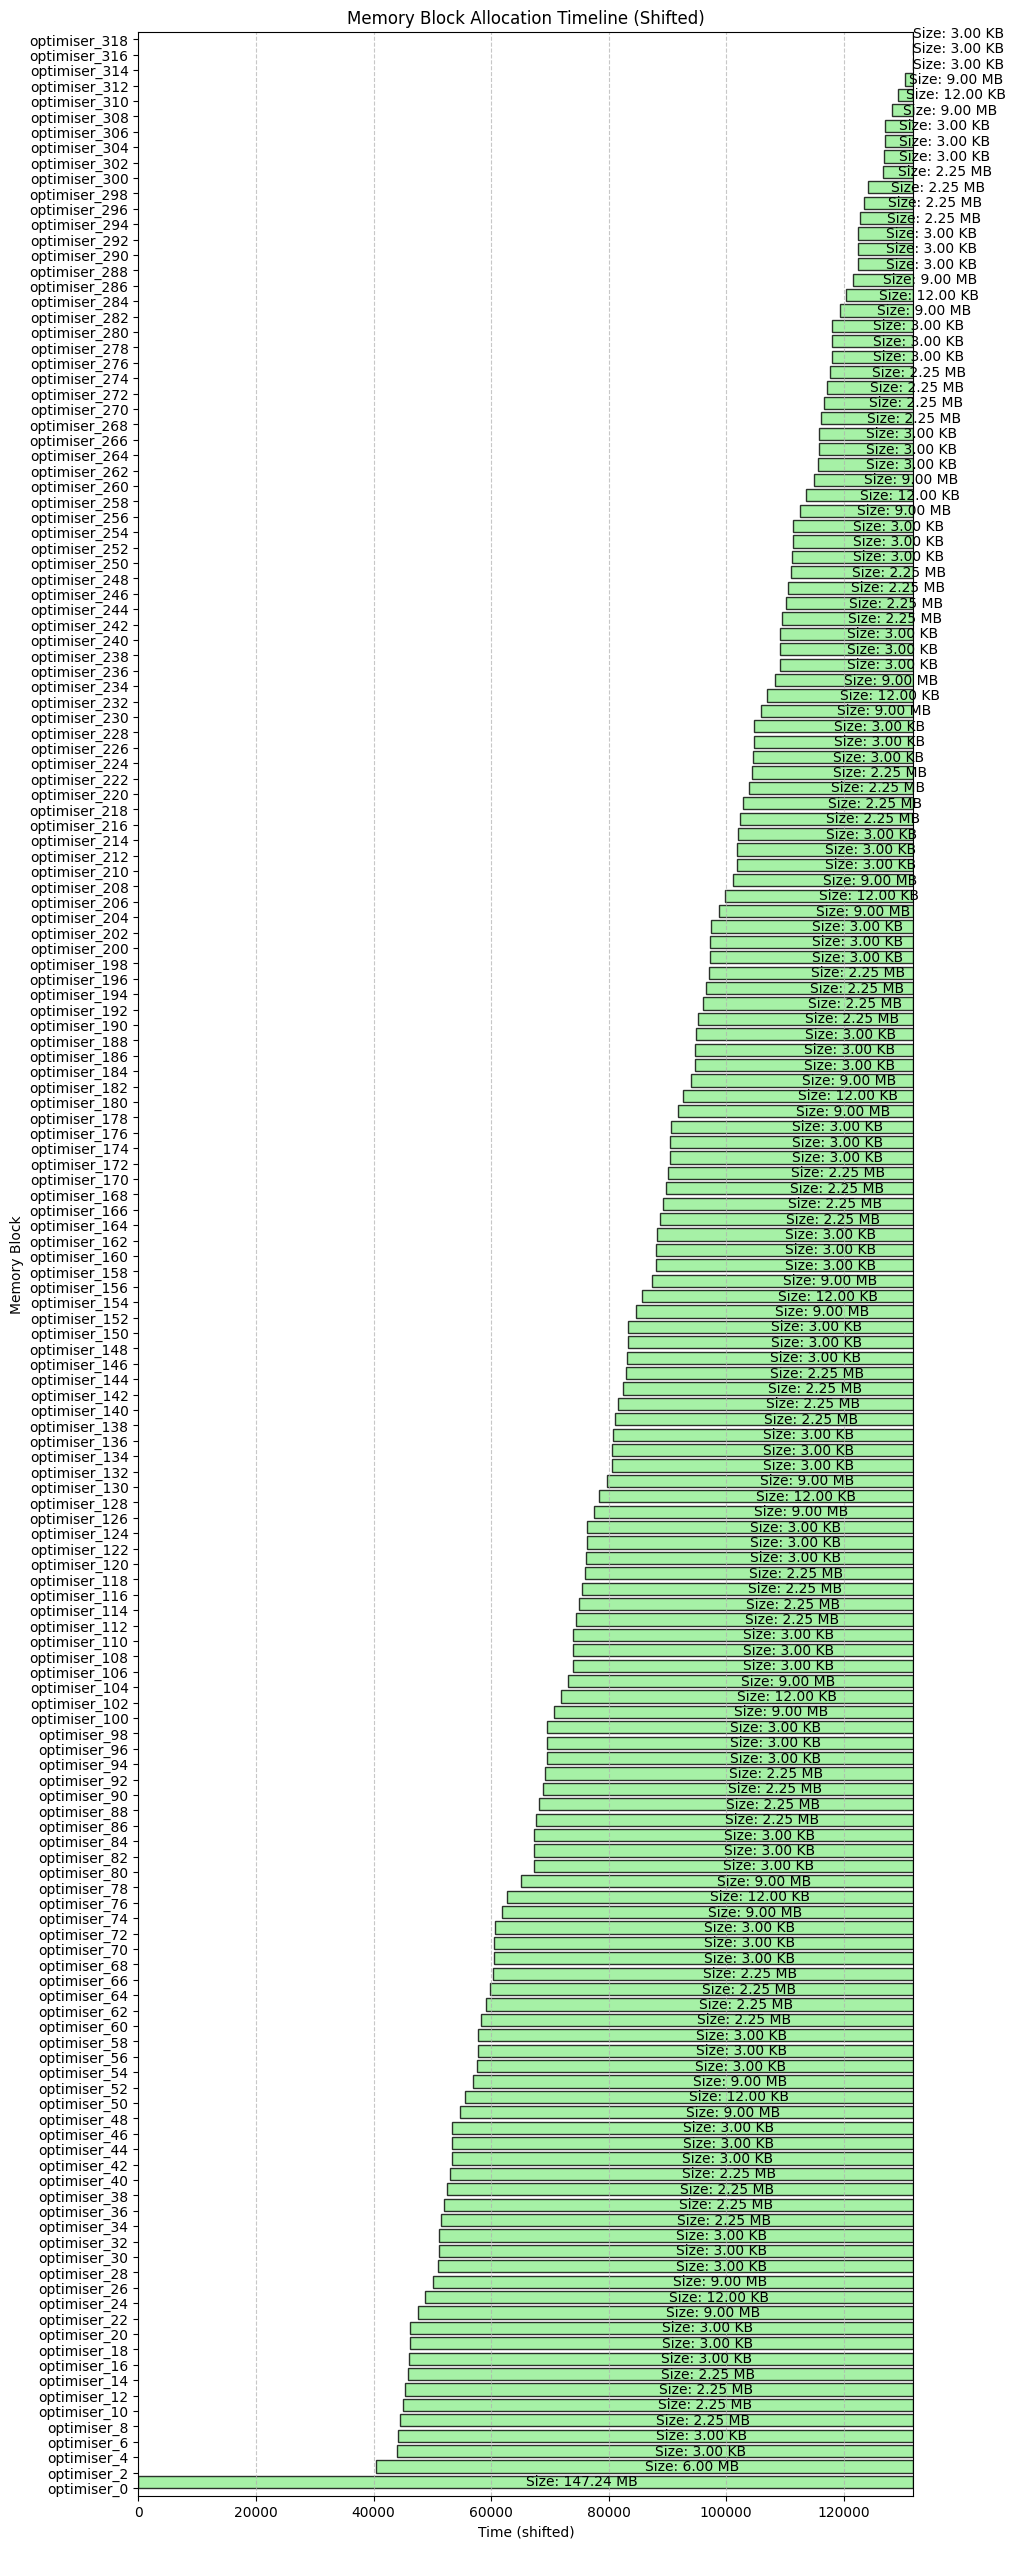

In [16]:
display_memory_lifecycle(opt_memory_blocks[::2])


## Snapshot

In [7]:
from experiments.snapshot import SnapshotAnalyser
import pickle

In [8]:
snap_analyser = SnapshotAnalyser(snapshot_path=neo_snapshot_file)
files = snap_analyser.group_by_file("transformers/models/opt/modeling_opt.py")
files.keys()

dict_keys([])

In [9]:
from typing import Dict, Tuple
class_line_ranges: Dict[str, Tuple[int, int]] = {
    "OPTLearnedPositionalEmbedding": (67, 92),
    "OPTAttention": (96, 266),
    "OptFlashAttention2": (270, 367),
    "OPTSdpaAttention": (371, 460),
    "OPTDecoderLayer": (464, 558),
    "OPTPreTrainedModel": (592, 624),
    "OPTDecoder": (628, 877),
    "OPTModel": (881, 942),
    "OPTForCausalLM": (946, 1081),
    "OPTForSequenceClassification": (1085, 1215),
    "OPTForQuestionAnswering": (1219, 1365),
}

for key in files.keys():
    line_no = key.split("/")[0]
    for key, value in class_line_ranges.items():
        if value[0] <= int(line_no) < value[1]:
            print(f"Line{line_no} is layer {key}")


In [17]:
gpu_memory_blocks = []
for index, layers in enumerate(list(snap_analyser.activity_blocks.values())[0:70]):
    for memory_block in layers:
        memory_info = {
            "alloc": memory_block.alloc_time,
            "free": memory_block.free_time,
            "size": memory_block.bytes,
            "name": memory_block.ops_name,
            "address": memory_block.address,
        }
        gpu_memory_blocks.append(memory_info)

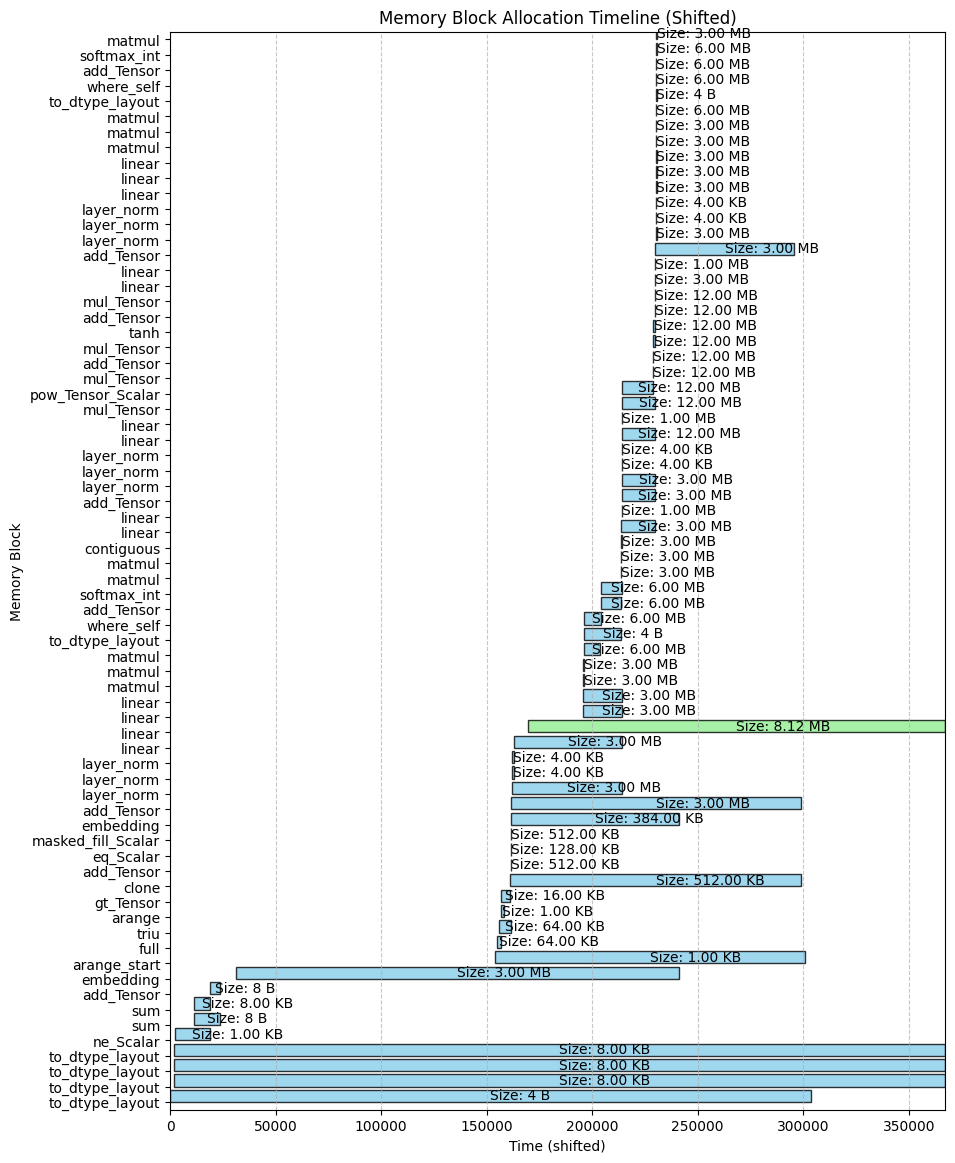

In [18]:
display_memory_lifecycle(gpu_memory_blocks)
